In [99]:
from gala import potential as gp
from gala import dynamics as gd
from gala import integrate as gi
from gala.units import galactic

from astropy import units as u

import numpy as np

from matplotlib import pyplot as plt

import matplotlib.animation as animation

import plotting_utils as pu

## Set up host potential and initial conditions

We'll simulate a (rough) Coma cluster analogue. However, there are many choices for gravitational potential.

The Navarro-Frenk-White profile is a mathematical model that descries the density distribution of dark matter halos. It is commonly used to understand the structure of galaxies and their formation

In [2]:
# initialize the potential model
# you need a unit system and all things that are passed in will be converted to it
host_potential = gp.NFWPotential.from_M200_c(1.26e15 * u.Msun, 4, units=galactic)

In [3]:
host_potential.units

<UnitSystem (kpc, Myr, solMass, rad)>

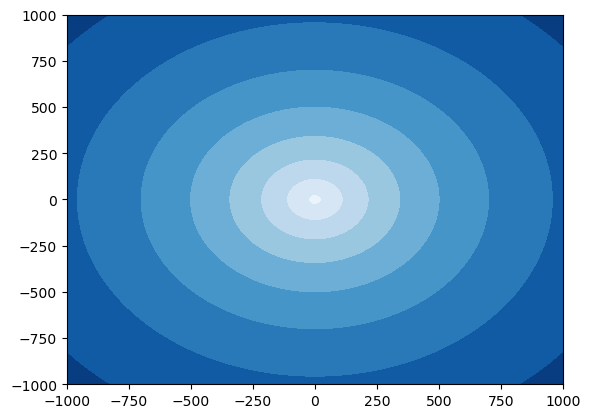

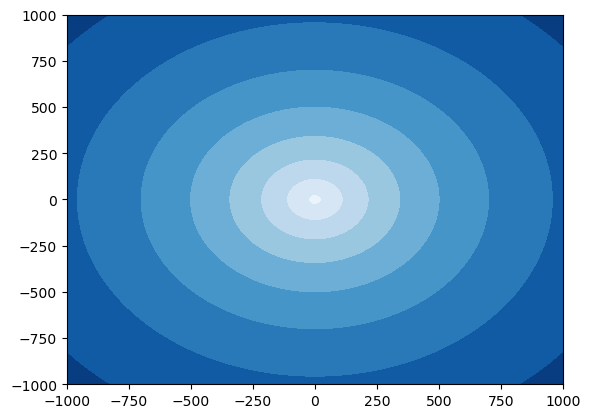

In [4]:
x = np.linspace(-1000, 1000, 100)
z = np.linspace(-1000, 1000, 100)
host_potential.plot_contours(grid=(x, 1., z))

In [5]:
def find_axes_limits(data, padding):
    data_min = np.nanmin(data)
    data_max = np.nanmax(data)
    range_padding = np.abs(data_max - data_min) * padding

    return data_min - range_padding, data_max + range_padding

def find_limits_multiple_axes(data, padding):
    '''
    data should include [[xdata, ydata], [xdata, ydata], ...] in the number of pairs of data
    '''
    position_y_lowerlim = np.zeros(3)
    position_y_upperlim = np.zeros(3)
    position_x_lowerlim = np.zeros(3)
    position_x_upperlim = np.zeros(3)

    for i in range(len(data)):
        position_x_lowerlim[i], position_x_upperlim[i] = find_axes_limits(data[i][0].value, padding)
        position_y_lowerlim[i], position_y_upperlim[i] = find_axes_limits(data[i][1].value, padding)

    position_x_lowerlim = np.nanmin(position_x_lowerlim)
    position_x_upperlim = np.nanmax(position_x_upperlim)
    position_y_lowerlim = np.nanmin(position_y_lowerlim)
    position_y_upperlim = np.nanmax(position_y_upperlim)

    return [position_x_lowerlim, position_x_upperlim], [position_y_lowerlim, position_y_upperlim]
    

In [306]:
class Orbit:
    def __init__(self, Gala_Potential, initial_conditions, dt=2., n_steps=2000):
        
        self.orbit = gp.Hamiltonian(Gala_Potential).integrate_orbit(initial_conditions, dt=dt, n_steps=n_steps)
        self.initial_conditions = initial_conditions

        self.x, self.y, self.z = self.orbit.xyz
        self.vx, self.vy, self.vz = self.orbit.v_xyz.to(u.km/u.s)
        self.t = self.orbit.t

        return
    
    def plot_orbit(self, *args, **kwargs):
        
        fig = self.orbit.plot(*args, **kwargs)

        return fig
    
    def calc_3d_tail_angles(self):
    
        vx, vy, vz = self.orbit.v_xyz.to(u.km/u.s)
        
        vx = np.array(vx)
        vy = np.array(vy)
        vz = np.array(vz)
        
        velocity_vectors = np.vstack((vx, vy, vz))
        
        velocity_vectors = velocity_vectors.T
        self.velocity_magnitudes = np.apply_along_axis(np.linalg.norm, axis=1, arr=velocity_vectors)
        velocity_magnitudes = self.velocity_magnitudes[:, np.newaxis]
        
        self.velocity_unit_vectors = velocity_vectors/velocity_magnitudes

        self.tail_angle_unit_vectors = -self.velocity_unit_vectors
        
        return
    
    def Animate_Orbit(self):

        fig, ax = plt.subplots(2, 3, figsize=(30, 20))

        orbit_lines = []
        galaxy_points = []
        data_combos = [[self.x, self.y], [self.x, self.z], [self.y, self.z], [self.vx, self.vy], [self.vx, self.vz], [self.vy, self.vz]]
    
        position_xlim, position_ylim = find_limits_multiple_axes(data_combos[0:3], 0.05)
        velocity_xlim, velocity_ylim = find_limits_multiple_axes(data_combos[3:], 0.05)

        labels = [['$x$ (kpc)', '$y$ (kpc)'], ['$x$ (kpc)', '$z$ (kpc)'], ['$y$ (kpc)', '$z$ (kpc)'], ['$v_x$ (km/s)', '$v_y$ (km/s)'], ['$v_x$ (km/s)', '$v_z$ (km/s)'], ['$v_y$ (km/s)', '$v_z$ (km/s)']]

        for i in range(3):
            ax[0][i].set_xlim(position_xlim)
            ax[0][i].set_ylim(position_ylim)
            ax[1][i].set_xlim(velocity_xlim)
            ax[1][i].set_ylim(velocity_ylim)

        current_data = 0
        time_labels = []
        for row in ax:
            for a in row:
                orbit_line, = a.plot([], [], lw=2)
                galaxy_point, = a.plot([], [], '*')
                time_text = a.text(0.05, 0.95, '', transform=a.transAxes, fontsize=12,
                              verticalalignment='top', horizontalalignment='left', 
                              bbox=dict(facecolor='white', alpha=0.5))
                orbit_lines.append(orbit_line)
                galaxy_points.append(galaxy_point)
                time_labels.append(time_text)
                a.plot(0, 0, color="black", marker="x")
                a.scatter(data_combos[current_data][0][0], data_combos[current_data][1][0], color='orange', marker='*', s=5, alpha=0.75)
                a.set_aspect('equal')
                a.set_xlabel(labels[current_data][0])
                a.set_ylabel(labels[current_data][1])

                current_data += 1

        def init():

            for orbit_line, galaxy_point, time_text in zip(orbit_lines, galaxy_points, time_labels):
                orbit_line.set_data([], [])
                galaxy_point.set_data([], [])
                time_text.set_text('')
            
            return(orbit_lines + galaxy_points)

        def update(frame):
            for i, (orbit_line, galaxy_point, time_text) in enumerate(zip(orbit_lines, galaxy_points, time_labels)):
                    orbit_line.set_data(data_combos[i][0][:frame].value, data_combos[i][1][:frame].value)
                    galaxy_point.set_data([data_combos[i][0][frame].value], [data_combos[i][1][frame].value])
                    time_text.set_text(f"Time = {self.t[frame]}")
            return (orbit_lines + galaxy_points)

        self.anim = animation.FuncAnimation(fig, update, init_func=init, frames=len(self.x), interval=10)
        plt.show()

        return fig
    
    # def plot_orbits_not_animated(self, time_index):
        
    #     fig, ax = plt.subplots(2, 3, figsize=(30, 20))

    #     orbit_lines = []
    #     galaxy_points = []
    #     data_combos = [[self.x, self.y], [self.x, self.z], [self.y, self.z], [self.vx, self.vy], [self.vx, self.vz], [self.vy, self.vz]]

    #     position_xlim, position_ylim = find_limits_multiple_axes(data_combos[0:3], 0.05)
    #     velocity_xlim, velocity_ylim = find_limits_multiple_axes(data_combos[3:], 0.05)
        
    #     labels = [['$x$ (kpc)', '$y$ (kpc)'], ['$x$ (kpc)', '$z$ (kpc)'], ['$y$ (kpc)', '$z$ (kpc)'], ['$v_x$ (km/s)', '$v_y$ (km/s)'], ['$v_x$ (km/s)', '$v_z$ (km/s)'], ['$v_y$ (km/s)', '$v_z$ (km/s)']]

    #     for i in range(3):
    #         ax[0][i].set_xlim(position_xlim)
    #         ax[0][i].set_ylim(position_ylim)
    #         ax[1][i].set_xlim(velocity_xlim)
    #         ax[1][i].set_ylim(velocity_ylim)

    #     current_data = 0
    #     time_labels = []
    #     for row in ax:
    #         for a in row:
    #             a.text(0.05, 0.95, self.t[time_index], transform=a.transAxes, fontsize=12,
    #                           verticalalignment='top', horizontalalignment='left', 
    #                           bbox=dict(facecolor='white', alpha=0.5))
    #             a.plot(0, 0, color="black", marker="x")
    #             a.plot(data_combos[current_data][0][0], data_combos[current_data][1][0], 'x', color='red')
    #             a.plot(data_combos[current_data][0][:time_index], data_combos[current_data][1][:time_index], alpha=0.75)
    #             a.plot(data_combos[current_data][0][time_index], data_combos[current_data][1][time_index], '*', markersize=10, color='orange')
    #             a.set_aspect('equal')
    #             a.set_xlabel(labels[current_data][0])
    #             a.set_ylabel(labels[current_data][1])

    #             current_data += 1


    #     return fig

    def plot_orbits_not_animated(self, time_index, with_tails=False):
        
        '''With_tails requires that you have already calculated 3-D tail angles'''

        fig, ax = plt.subplots(2, 3, figsize=(30, 20))

        orbit_lines = []
        galaxy_points = []
        data_combos = [[self.x, self.y], [self.x, self.z], [self.y, self.z], [self.vx, self.vy], [self.vx, self.vz], [self.vy, self.vz]]

        position_xlim, position_ylim = pu.find_limits_multiple_axes(data_combos[0:3], 0.05)
        velocity_xlim, velocity_ylim = pu.find_limits_multiple_axes(data_combos[3:], 0.05)
        
        labels = [['$x$ (kpc)', '$y$ (kpc)'], ['$x$ (kpc)', '$z$ (kpc)'], ['$y$ (kpc)', '$z$ (kpc)'], ['$v_x$ (km/s)', '$v_y$ (km/s)'], ['$v_x$ (km/s)', '$v_z$ (km/s)'], ['$v_y$ (km/s)', '$v_z$ (km/s)']]

        for i in range(3):
            ax[0][i].set_xlim(position_xlim)
            ax[0][i].set_ylim(position_ylim)
            ax[1][i].set_xlim(velocity_xlim)
            ax[1][i].set_ylim(velocity_ylim)

        current_data = 0
        time_labels = []
        for row in ax:
            for a in row:
                a.text(0.05, 0.95, self.t[time_index], transform=a.transAxes, fontsize=12,
                              verticalalignment='top', horizontalalignment='left', 
                              bbox=dict(facecolor='white', alpha=0.5))
                a.plot(0, 0, color="black", marker="x")
                a.plot(data_combos[current_data][0][0], data_combos[current_data][1][0], 'x', color='red')
                a.plot(data_combos[current_data][0][:time_index], data_combos[current_data][1][:time_index], alpha=0.75)
                a.plot(data_combos[current_data][0][time_index], data_combos[current_data][1][time_index], '*', markersize=10, color='orange')
                a.set_aspect('equal')
                a.set_xlabel(labels[current_data][0])
                a.set_ylabel(labels[current_data][1])

                current_data += 1

        if with_tails:
            
            component_indices = {'$x$ (kpc)': 0, '$y$ (kpc)': 1, '$z$ (kpc)': 2}

            for i, a in enumerate(ax[0]):
                x_index = component_indices[labels[i][0]]
                y_index = component_indices[labels[i][1]]
                print(f"{x_index}, {y_index}")
                tail_x_points = data_combos[i][0][time_index-20:time_index:-1]
                # fix this based on what the chatGPT says
                print(f"x_points: {tail_x_points}")
                # tail_y_points = pu.vector_to_tail_line(self.tail_angle_unit_vectors[time_index,[x_index, y_index]], [data_combos[i][0][time_index], data_combos[i][1][time_index]], tail_x_points)


                # solution: normalize 2-D projected vector
                galaxy_x = data_combos[i][0][time_index].value
                galaxy_y = data_combos[i][1][time_index].value
                tail_length = 10000
                tail_distance = 10000
                steps = np.linspace(0, tail_distance, tail_length)  # negative to go backward
                tail_x_points = galaxy_x + steps * self.tail_angle_unit_vectors[time_index, x_index]
                tail_y_points = galaxy_y + steps * self.tail_angle_unit_vectors[time_index, y_index]

                tail_point_selection = np.abs(tail_y_points - data_combos[i][1][time_index].value) < 50
                tail_x_points_selected = tail_x_points[tail_point_selection]
                tail_y_points_selected = tail_y_points[tail_point_selection]
                
                a.plot(tail_x_points_selected, tail_y_points_selected, '-', color='red')

        return fig
        
    
    def calc_2d_tail_angles_and_orbit(self, view_dir):
    
        '''view_dir is the direction the observer is looking towards!!'''

        # ensure the view_dir vector is normalized
        view_dir_normed = view_dir/np.linalg.norm(view_dir)

        # define another vector in the basis (not parallel to view_dir)
        if np.allclose(view_dir_normed, [0, 0, 1]):
            up = np.array([0, 1, 0])
        else:
            up = np.array([0, 0, 1])

        # define a rightwards basis vector perpendicular to the view direction and up vector!
        right = np.cross(up, view_dir_normed)
        right /= np.linalg.norm(right)

        # redefine the up vector so it is orthogonal to both
        up = np.cross(view_dir, right)

        # transform cartesian basis vectors into viewer's basis
        rot_matrix = np.vstack([right, up, view_dir_normed]).T
        rotated_tail_angles = [rot_matrix @ tail_angle_vector for tail_angle_vector in self.tail_angle_unit_vectors]
        rotated_tail_angles = np.array(rotated_tail_angles)

        # take only the x and y (up and right) components to get the projection in 2D
        tail_angles_2d_vectors = rotated_tail_angles[:, :2]
        tail_angles_2d = np.arctan2(tail_angles_2d_vectors[:,1], tail_angles_2d_vectors[:,0])

        return tail_angles_2d_vectors, tail_angles_2d


In [307]:
dir(host_potential)

['G',
 'R',
 'Wrapper',
 '_GSL_only',
 '_R',
 '__abstractmethods__',
 '__add__',
 '__call__',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__signature__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_abc_impl',
 '_density',
 '_energy',
 '_get_c_valid_arr',
 '_gradient',
 '_hessian',
 '_parameters',
 '_parse_parameter_values',
 '_prepare_parameters',
 '_remove_units',
 '_remove_units_prepare_shape',
 '_setup_potential',
 '_setup_wrapper',
 '_units',
 '_validate_prepare_time',
 '_validate_units',
 '_value',
 '_vc_rs_rref_to_m',
 'a',
 'acceleration',
 'as_interop',
 'b',
 'c',
 'c_instance',
 'c_parameters',
 'circular_velocity',
 'density',
 'energy',
 'from_M200_c',
 'from_circular_velocity',
 'gradient',


In [308]:
host_potential.m

<PotentialParameter: m [mass]>

In [309]:
x.unit

Unit("kpc")

In [310]:
# use gd.PhaseSpacePosition to define initial conditions and other positions in phase space, using cartesian position and velocity vectors
# pass them in with units when the potential also has unit system--you can use any length and velocity units
initial_conditions = gd.PhaseSpacePosition(pos=[400,0,0.] * u.kpc,
                                           vel=[50,1200, 100] * u.km/u.s)
 
# this returns an Orbit class, which represents a collection of phase-space positions at times
orbit = gp.Hamiltonian(host_potential).integrate_orbit(initial_conditions, dt=2., n_steps=2000)

In [311]:
orbit2 = Orbit(host_potential, initial_conditions)

In [312]:
dir(initial_conditions)

['__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattr__',
 '__getattribute__',
 '__getitem__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_get_extra_mappings',
 '_plot_prepare',
 'angular_momentum',
 'basegeodetic',
 'cartesian',
 'cylindrical',
 'data',
 'energy',
 'frame',
 'from_hdf5',
 'from_w',
 'get_components',
 'grs80geodetic',
 'guiding_radius',
 'kinetic_energy',
 'ndcartesian',
 'ndim',
 'physicsspherical',
 'plot',
 'pos',
 'pos_components',
 'potential_energy',
 'radial',
 'represent_as',
 'representation_mappings',
 'reshape',
 'shape',
 'spherical',
 'to_coord_frame',
 'to_frame',
 'to_hdf5',
 'unitspherical',
 'v_x',
 'v_xyz',
 'v_y',
 'v_z',
 'vel',
 'vel_components',
 'w',
 'wgs72geodetic',
 'wgs84geodetic'

In [313]:
orbit2.tail_angle_unit_vectors

AttributeError: 'Orbit' object has no attribute 'tail_angle_unit_vectors'

In [314]:
initial_conditions.v_xyz

<Quantity [  50., 1200.,  100.] km / s>

In [315]:
orbit2.calc_3d_tail_angles()

0, 1
x_points: [] kpc
0, 2
x_points: [] kpc
1, 2
x_points: [] kpc


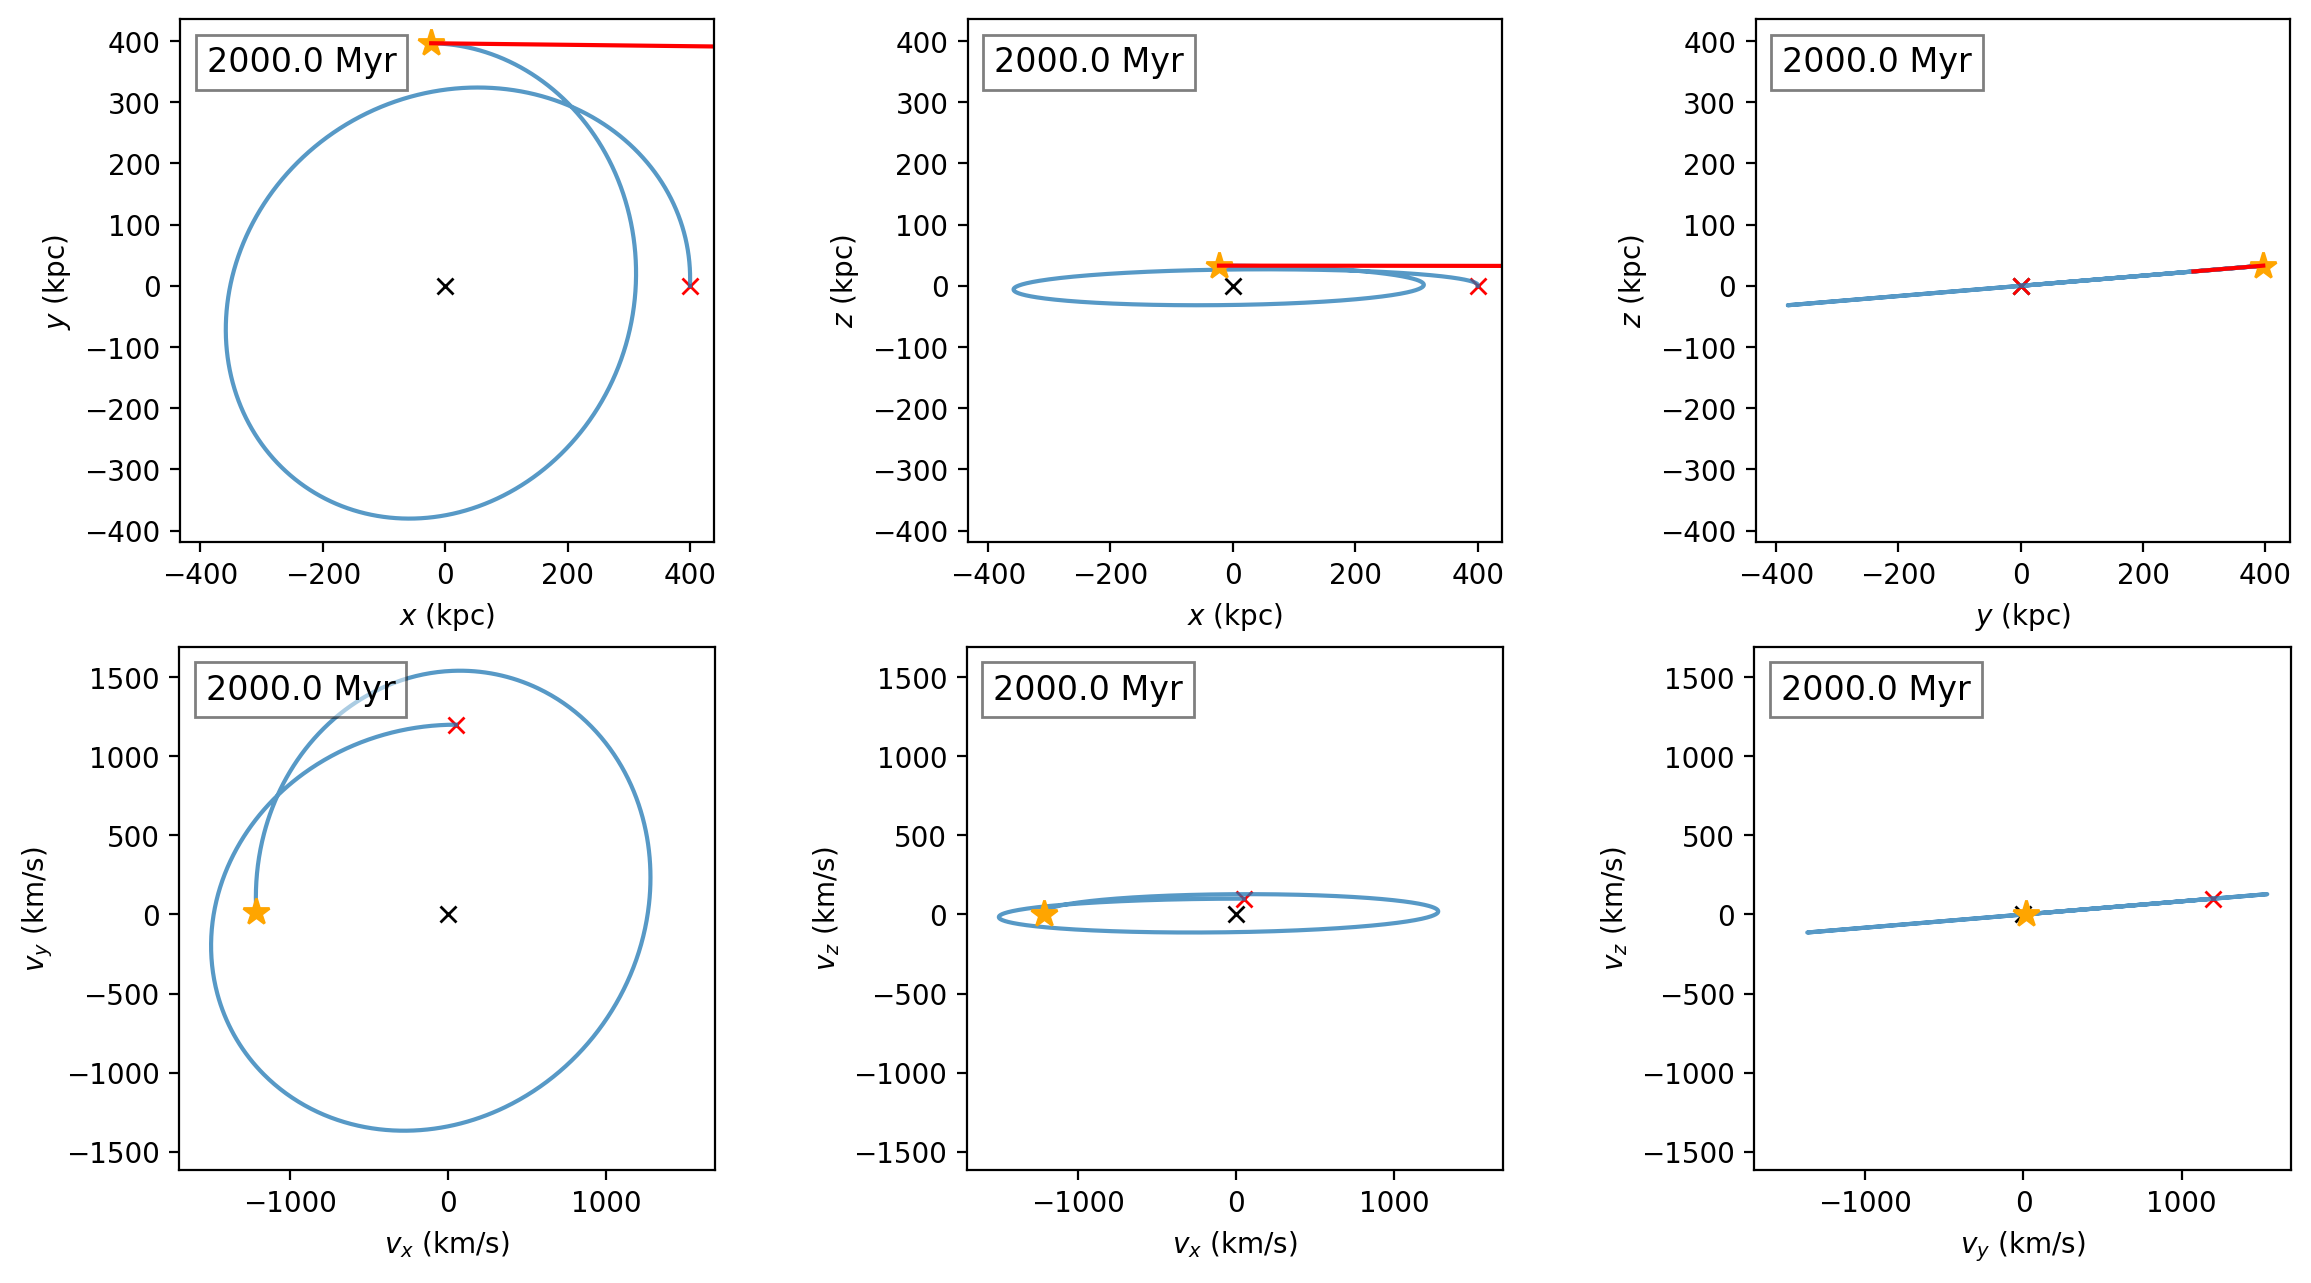

In [316]:
orbit2.plot_orbits_not_animated(1000, with_tails=True)

In [321]:
tail_vectors_2d = orbit2.calc_2d_tail_angles_and_orbit([1, 0, 1])

In [322]:
tail_vectors_2d

array([[ 0.93701631, -0.04148699],
       [ 0.93731225, -0.03302264],
       [ 0.937541  , -0.02455352],
       ...,
       [-0.93782092, -0.00244887],
       [-0.93776892, -0.01081216],
       [-0.93765122, -0.01918024]])

In [320]:
orbit2.tail_angle_unit_vectors

array([[-0.04148699, -0.99568778, -0.08297398],
       [-0.03302264, -0.99600225, -0.08300019],
       [-0.02455352, -0.99624532, -0.08302044],
       ...,
       [-0.00244887,  0.99654277,  0.08304523],
       [-0.01081216,  0.99648751,  0.08304063],
       [-0.01918024,  0.99636244,  0.0830302 ]])

In [11]:
%matplotlib qt

In [12]:
orbit2.Animate_Orbit()

NameError: name 'orbit2' is not defined

In [20]:
orbit2.calc_3d_tail_angles()

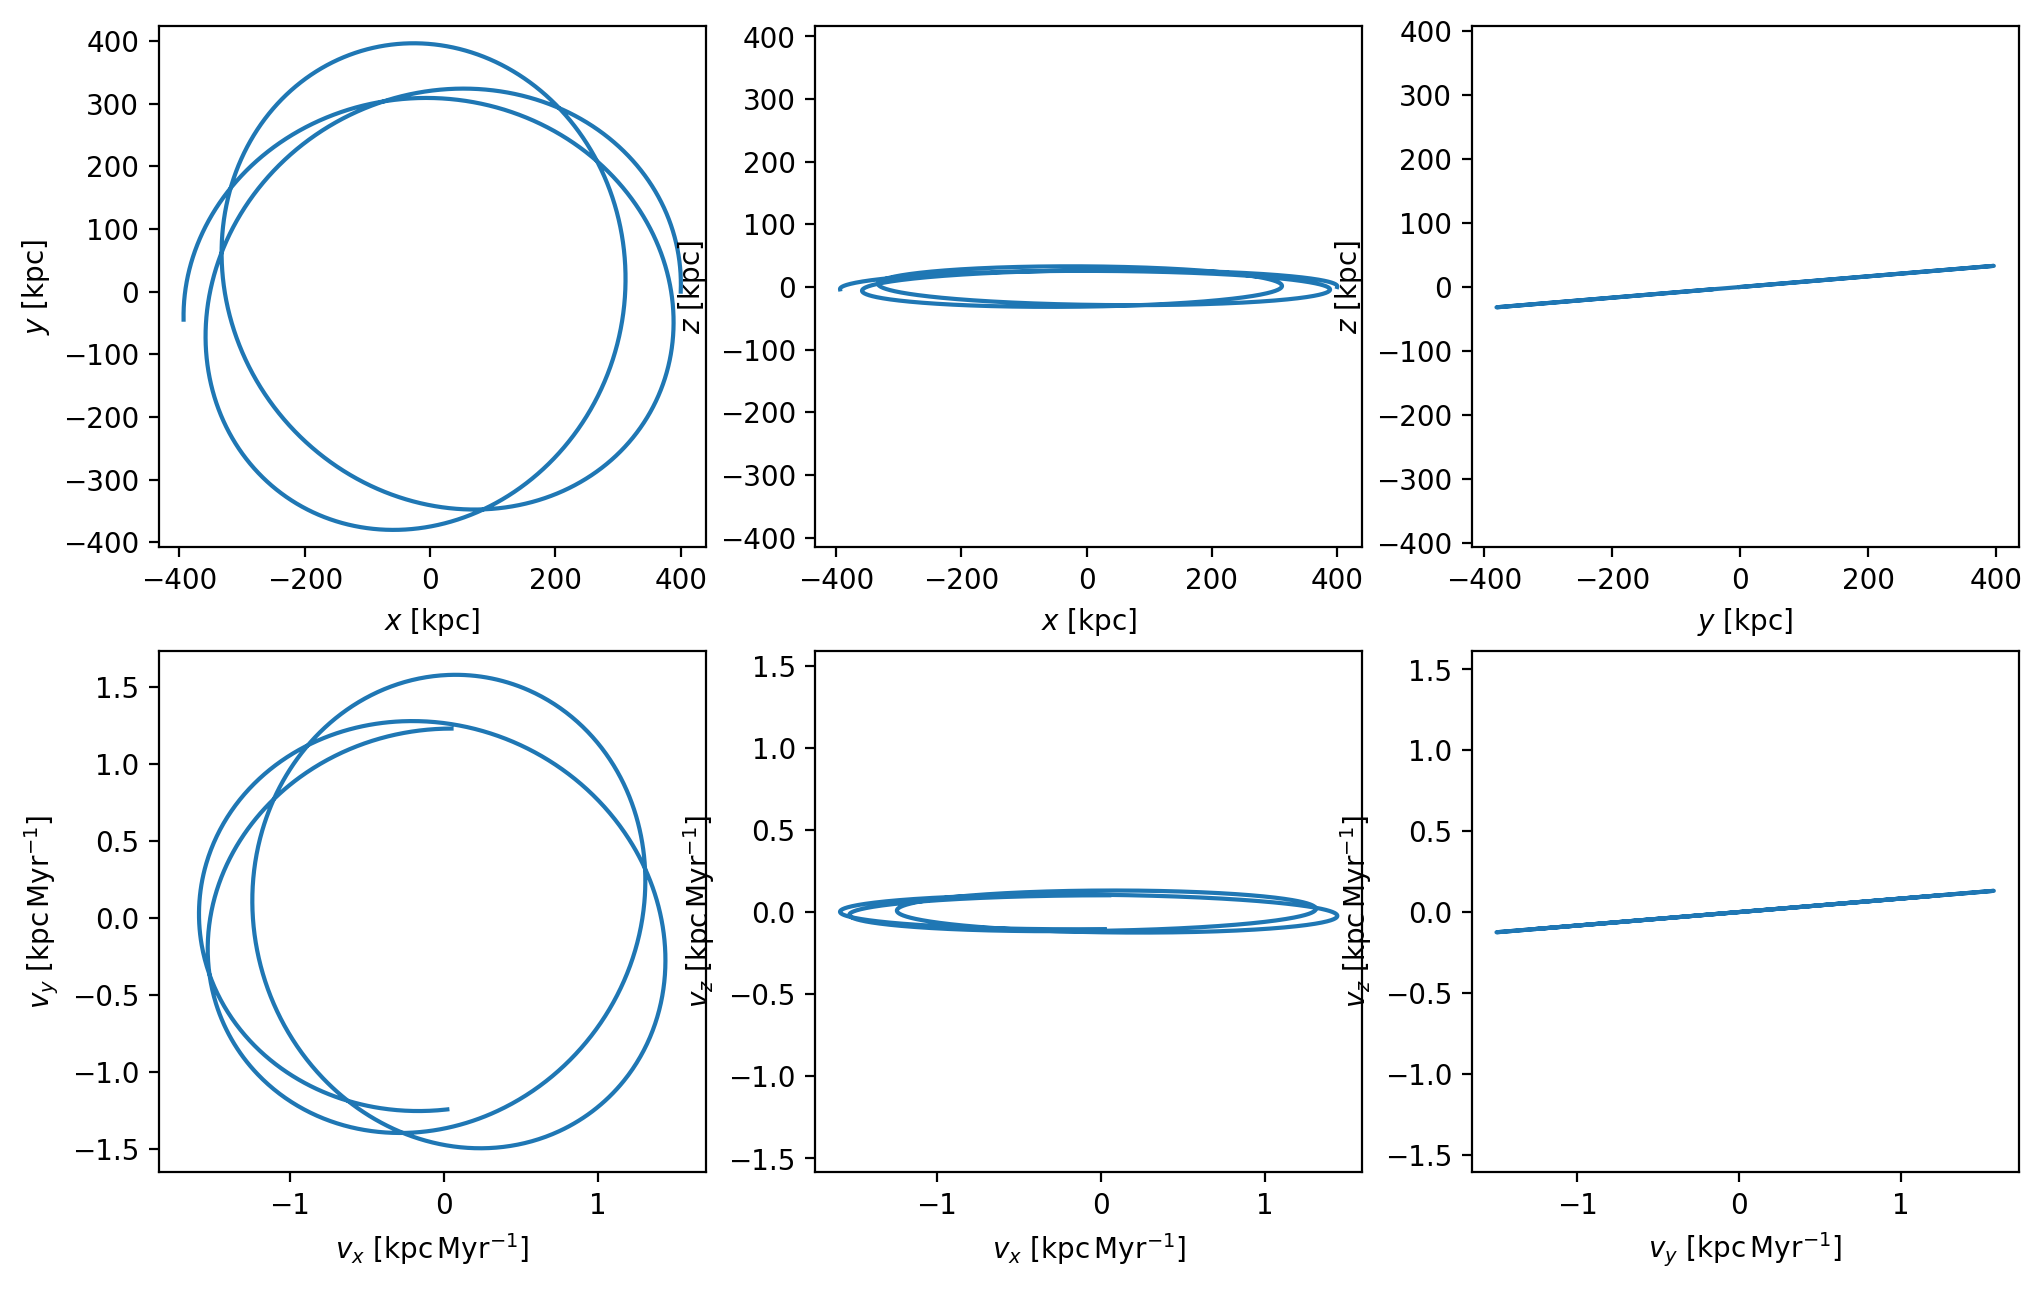

In [27]:
orbit2.plot_orbits_not_animated()

In [104]:
orbit2.tail_angle_unit_vectors.shape

(2001, 3)

In [101]:
fig = orbit.plot()

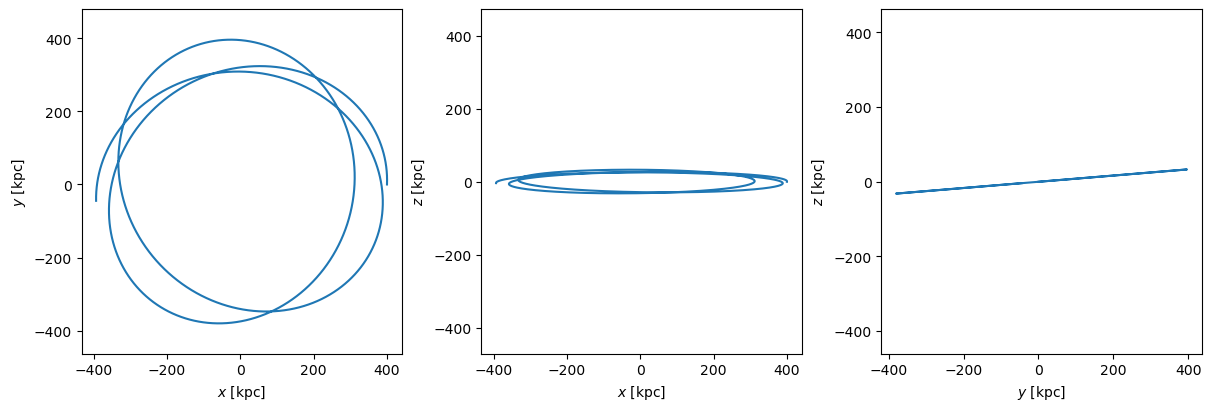

In [14]:
help(orbit.plot)

Help on method plot in module gala.dynamics.orbit:

plot(components=None, units=None, auto_aspect=True, **kwargs) method of gala.dynamics.orbit.Orbit instance
    Plot the positions in all projections. This is a wrapper around
    `~gala.dynamics.plot_projections` for fast access and quick
    visualization. All extra keyword arguments are passed to that function
    (the docstring for this function is included here for convenience).
    
    Parameters
    ----------
    components : iterable (optional)
        A list of component names (strings) to plot. By default, this is the
        Cartesian positions ``['x', 'y', 'z']``. To plot Cartesian
        velocities, pass in the velocity component names
        ``['v_x', 'v_y', 'v_z']``. If the representation is different, the
        component names will be different. For example, for a Cylindrical
        representation, the components are ``['rho', 'phi', 'z']`` and
        ``['v_rho', 'pm_phi', 'v_z']``.
    units : `~astropy.units.U

In [35]:
dir(initial_conditions)

['__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattr__',
 '__getattribute__',
 '__getitem__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_get_extra_mappings',
 '_plot_prepare',
 'angular_momentum',
 'basegeodetic',
 'cartesian',
 'cylindrical',
 'data',
 'energy',
 'frame',
 'from_hdf5',
 'from_w',
 'get_components',
 'grs80geodetic',
 'guiding_radius',
 'kinetic_energy',
 'ndcartesian',
 'ndim',
 'physicsspherical',
 'plot',
 'pos',
 'pos_components',
 'potential_energy',
 'radial',
 'represent_as',
 'representation_mappings',
 'reshape',
 'shape',
 'spherical',
 'to_coord_frame',
 'to_frame',
 'to_hdf5',
 'unitspherical',
 'v_x',
 'v_xyz',
 'v_y',
 'v_z',
 'vel',
 'vel_components',
 'w',
 'wgs72geodetic',
 'wgs84geodetic'

In [6]:
dir(orbit)

['__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattr__',
 '__getattribute__',
 '__getitem__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_get_extra_mappings',
 '_max_helper',
 '_max_return_helper',
 '_plot_prepare',
 'align_circulation_with_z',
 'angular_momentum',
 'animate',
 'apocenter',
 'basegeodetic',
 'cartesian',
 'circulation',
 'cylindrical',
 'data',
 'eccentricity',
 'energy',
 'estimate_period',
 'frame',
 'from_galpy_orbit',
 'from_hdf5',
 'from_w',
 'get_components',
 'grs80geodetic',
 'guiding_radius',
 'hamiltonian',
 'kinetic_energy',
 'ndcartesian',
 'ndim',
 'norbits',
 'ntimes',
 'orbit_gen',
 'pericenter',
 'physicsspherical',
 'plot',
 'plot_3d',
 'pos',
 'pos_components',
 'potential',
 'potential_en

In [7]:
orbit.t

<Quantity [0.000e+00, 2.000e+00, 4.000e+00, ..., 3.996e+03, 3.998e+03,
           4.000e+03] Myr>

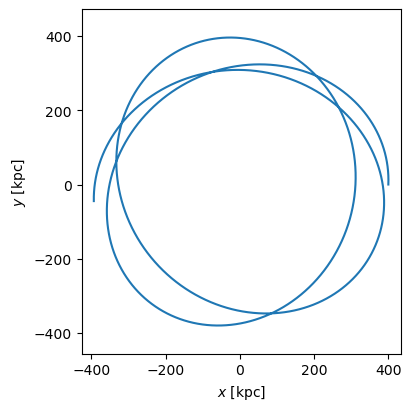

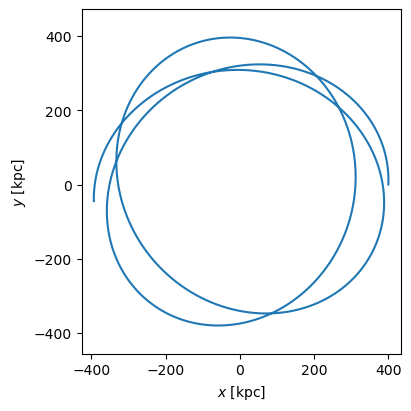

In [8]:
orbit.plot(['x', 'y'])

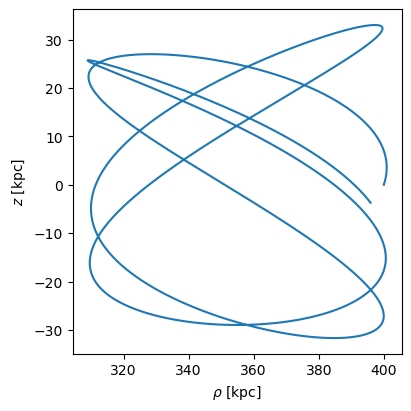

In [9]:
# transform into cylindrical coordiantes:
fig = orbit.cylindrical.plot(['rho', 'z'])  

In [22]:
x, y, z = orbit.xyz
vx, vy, vz = orbit.v_xyz.to(u.km/u.s)

fig, ax = plt.subplots(2, 3, figsize=(12, 8))

lims = 450
vlims = 2000

def plot_orbit(axis, a, b, lims=lims):

    axis.scatter(0, 0, color="black", marker="x", s=50)
    axis.scatter(a[0], b[0], color="red", marker="x", s=50)
    axis.plot(a, b)
    
    axis.set_xlim(-lims, lims)
    axis.set_ylim(-lims, lims)


plot_orbit(ax[0, 0], x, y)
plot_orbit(ax[0, 1], x, z)
plot_orbit(ax[0, 2], y, z)

plot_orbit(ax[1, 0], vx, vy, lims=vlims)
plot_orbit(ax[1, 1], vx, vz, lims=vlims)
plot_orbit(ax[1, 2], vy, vz, lims=vlims)


ax[0, 0].set(xlabel="x (kpc)", ylabel="y (kpc)")
ax[0, 1].set(xlabel="x (kpc)", ylabel="z (kpc)")
ax[0, 2].set(xlabel="y (kpc)", ylabel="z (kpc)")

ax[1, 0].set(xlabel="vx (km/s)", ylabel="vy (km/s)")
ax[1, 1].set(xlabel="vx (km/s)", ylabel="vz (km/s)")
ax[1, 2].set(xlabel="vy (km/s)", ylabel="vz (km/s)")

plt.tight_layout()
plt.show()


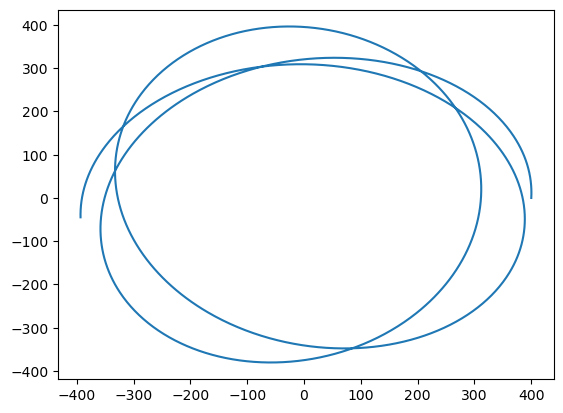

In [11]:
plt.plot(x, y)

In [12]:
%matplotlib qt

In [13]:
def calc_3d_tail_angles(orbit):
    
    vx, vy, vz = orbit.v_xyz.to(u.km/u.s)
    
    vx = np.array(vx)
    vy = np.array(vy)
    vz = np.array(vz)
    
    velocity_vectors = np.vstack((vx, vy, vz))
    
    print(velocity_vectors.shape)
    print(vx.shape)
    
    velocity_vectors = velocity_vectors.T
    velocity_magnitudes = np.apply_along_axis(np.linalg.norm, axis=1, arr=velocity_vectors)
    velocity_magnitudes = velocity_magnitudes[:, np.newaxis]
    
    velocity_unit_vectors = velocity_vectors/velocity_magnitudes
    
    return velocity_unit_vectors

In [14]:
def vector_to_tail_line(tail_vector, gal_position, x_vals, length=50):
    
    '''
    A function to calculate a line to draw a tail on a galaxy plot, given a galaxy position (a 2-d point, doesn't matter whether its xy, xz, etc.).
    
    '''
    
    line_slope = tail_vector[1]/tail_vector[0]
    
    # if np.abs(line_slope)<0.001:
    #     print('Oops')
    
    y_points = gal_position[1] + line_slope*(x_vals - gal_position[0])
    
    return y_points

In [15]:
velocity_unit_vectors = calc_3d_tail_angles(orbit)

(3, 2001)
(2001,)


In [16]:
velocity_unit_vectors

array([[ 0.04148699,  0.99568778,  0.08297398],
       [ 0.03302264,  0.99600225,  0.08300019],
       [ 0.02455352,  0.99624532,  0.08302044],
       ...,
       [ 0.00244887, -0.99654277, -0.08304523],
       [ 0.01081216, -0.99648751, -0.08304063],
       [ 0.01918024, -0.99636244, -0.0830302 ]])

In [17]:
plt.ion()

fig, ax = plt.subplots(1, 3)

orbit_lines = []
galaxy_points = []


position_line_xy, = ax[0].plot([], [], lw=2)
tail_line_xy, = ax[0].plot([], [], lw=2, color='red')
position_xy, = ax[0].plot([], [], '*')
position_line_xz, = ax[1].plot([], [], lw=2)
position_xz, = ax[1].plot([], [], '*')
position_line_yz, = ax[2].plot([], [], lw=2)
position_yz, = ax[2].plot([], [], '*')


for a in ax:
    a.plot(0, 0, color="black", marker="x")
    a.set_xlim(-450, 450)
    a.set_ylim(-450, 450)
    a.set_aspect('equal')

def init():
    position_line_xy.set_data([], [])
    position_xy.set_data([], [])
    
    position_line_xz.set_data([], [])
    position_xz.set_data([], [])
    
    position_line_yz.set_data([], [])
    position_yz.set_data([], [])
    
    tail_line_xy.set_data([], [])
    
    return([position_line_xy, position_xy, position_line_xz, position_xz, position_line_yz, position_yz, tail_line_xy])

def update(frame):
    position_line_xy.set_data(x[:frame].value, y[:frame].value)
    position_xy.set_data([x[frame].value], [y[frame].value])
    
    position_line_xz.set_data(x[:frame].value, z[:frame].value)
    position_xz.set_data([x[frame].value], [z[frame].value])
    
    position_line_yz.set_data(y[:frame].value, z[:frame].value)
    position_yz.set_data([y[frame].value], [z[frame].value])
    
    tail_x_points = x[frame-20:frame]
#     print(velocity_unit_vectors[frame, 0:1])
    tail_y_points = vector_to_tail_line(velocity_unit_vectors[frame,0:2], [x[frame], y[frame]], tail_x_points)
    tail_point_selection = np.abs(tail_y_points.value - y[frame].value < 50)
    tail_x_points_selected = tail_x_points[tail_point_selection]
    tail_y_points_selected = tail_y_points[tail_point_selection]
    tail_line_xy.set_data(tail_x_points_selected, tail_y_points_selected)
    
    return ([position_line_xy, position_xy, position_line_xz, position_xz, position_line_yz, position_yz, tail_line_xy])

# for i in range(len(x)):
    
#     orbit_plot = plt.plot(x[:i], y[:i])
#     plots.append(orbit_plot)

# animation_interval=0.01

# ani = animation.ArtistAnimation(fig, plots, interval=animation_interval, blit=True)
anim = animation.FuncAnimation(fig, update, init_func=init, frames=len(x), interval=10)
plt.show()


In [18]:
plt.ion()

fig, ax = plt.subplots(2, 3)

orbit_lines = []
galaxy_points = []
data_combos = [[x, y], [x, z], [y, z], [vx, vy], [vx, vz], [vy, vz]]


position_xlim, position_ylim = find_limits_multiple_axes(data_combos[0:3], 0.05)
velocity_xlim, velocity_ylim = find_limits_multiple_axes(data_combos[3:], 0.05)

# position_y_lowerlim = np.zeros(3)
# position_y_upperlim = np.zeros(3)
# position_x_lowerlim = np.zeros(3)
# position_x_upperlim = np.zeros(3)
# for i in range(3):
#     position_x_lowerlim[i], position_x_upperlim[i] = find_axes_limits(data_combos[i][0].value, 0.05)
#     position_y_lowerlim[i], position_y_upperlim[i] = find_axes_limits(data_combos[i][1].value, 0.05)
# position_x_lowerlim = np.nanmin(position_x_lowerlim)
# position_x_upperlim = np.nanmax(position_x_upperlim)
# position_y_lowerlim = np.nanmin(position_y_lowerlim)
# position_y_upperlim = np.nanmax(position_y_upperlim)

for i in range(3):
    ax[0][i].set_xlim(position_xlim)
    ax[0][i].set_ylim(position_ylim)
    ax[1][i].set_xlim(velocity_xlim)
    ax[1][i].set_ylim(velocity_ylim)

current_data = 0
for row in ax:
    for a in row:
        orbit_line, = a.plot([], [], lw=2)
        galaxy_point, = a.plot([], [], '*')
        orbit_lines.append(orbit_line)
        galaxy_points.append(galaxy_point)
        a.plot(0, 0, color="black", marker="x")
        a.scatter(data_combos[current_data][0][0], data_combos[current_data][1][0], color='orange', marker='*', s=5, alpha=0.75)
        
        # set the limits
        # xlims = find_axes_limits(data_combos[current_data][0].value, 0.05)
        # ylims = find_axes_limits(data_combos[current_data][1].value, 0.05)
        # xmin = np.nanmin(data_combos[current_data][0])
        # xmax = np.nanmax(data_combos[current_data][0])

        # a.set_xlim(-450, 450)
        # a.set_ylim(-450, 450)
        a.set_aspect('equal')
        current_data += 1


def init():

    for orbit_line, galaxy_point in zip(orbit_lines, galaxy_points):
        orbit_line.set_data([], [])
        galaxy_point.set_data([], [])
    
    return(orbit_lines + galaxy_points)

def update(frame):

    for i, (orbit_line, galaxy_point) in enumerate(zip(orbit_lines, galaxy_points)):
            orbit_line.set_data(data_combos[i][0][:frame].value, data_combos[i][1][:frame].value)
            galaxy_point.set_data([data_combos[i][0][frame].value], [data_combos[i][1][frame].value])

#     position_line_xy.set_data(x[:frame].value, y[:frame].value)
#     position_xy.set_data([x[frame].value], [y[frame].value])
    
#     position_line_xz.set_data(x[:frame].value, z[:frame].value)
#     position_xz.set_data([x[frame].value], [z[frame].value])
    
#     position_line_yz.set_data(y[:frame].value, z[:frame].value)
#     position_yz.set_data([y[frame].value], [z[frame].value])
    
#     tail_x_points = x[frame-20:frame]
# #     print(velocity_unit_vectors[frame, 0:1])
#     tail_y_points = vector_to_tail_line(velocity_unit_vectors[frame,0:2], [x[frame], y[frame]], tail_x_points)
#     tail_point_selection = np.abs(tail_y_points.value - y[frame].value < 50)
#     tail_x_points_selected = tail_x_points[tail_point_selection]
#     tail_y_points_selected = tail_y_points[tail_point_selection]
#     tail_line_xy.set_data(tail_x_points_selected, tail_y_points_selected)
    
    return (orbit_lines + galaxy_points)

# for i in range(len(x)):
    
#     orbit_plot = plt.plot(x[:i], y[:i])
#     plots.append(orbit_plot)

# animation_interval=0.01

# ani = animation.ArtistAnimation(fig, plots, interval=animation_interval, blit=True)
anim = animation.FuncAnimation(fig, update, init_func=init, frames=len(x), interval=10)
plt.show()


In [99]:
orbit.animate()

(<Figure size 1200x400 with 3 Axes>,
 <matplotlib.animation.FuncAnimation at 0x154b686a0>)

(3, 2001)
(2001,)


array([[ 0.04148699,  0.99568778,  0.08297398],
       [ 0.03302264,  0.99600225,  0.08300019],
       [ 0.02455352,  0.99624532,  0.08302044],
       ...,
       [ 0.00244887, -0.99654277, -0.08304523],
       [ 0.01081216, -0.99648751, -0.08304063],
       [ 0.01918024, -0.99636244, -0.0830302 ]])

In [96]:
[vx[0].value, vy[0].value, vz[0].value]/np.sqrt(vx[0]**2+vy[0]**2+vz[0]**2)

<Quantity [0.04148699, 0.99568778, 0.08297398] s / km>

In [13]:
x[:20].value

array([400.        , 400.09182356, 400.16275518, 400.21279887,
       400.24195923, 400.2502415 , 400.23765151, 400.20419573,
       400.14988121, 400.07471564, 399.9787073 , 399.86186508,
       399.72419849, 399.56571764, 399.38643324, 399.18635663,
       398.96549972, 398.72387507, 398.4614958 , 398.17837568])

Traceback (most recent call last):
  File "/Users/ana/opt/anaconda3/envs/a330/lib/python3.9/site-packages/matplotlib/cbook.py", line 298, in process
    func(*args, **kwargs)
  File "/Users/ana/opt/anaconda3/envs/a330/lib/python3.9/site-packages/matplotlib/animation.py", line 892, in _start
    self._init_draw()
  File "/Users/ana/opt/anaconda3/envs/a330/lib/python3.9/site-packages/matplotlib/animation.py", line 1729, in _init_draw
    self._drawn_artists = self._init_func()
  File "/var/folders/fg/s5hgpbts0y1d6s97brt4xjbm0000gn/T/ipykernel_13648/1594711057.py", line 21, in init
    return(orbit_line,)
NameError: name 'orbit_line' is not defined
